In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

df = pd.read_csv('../../data/clean/cleaned_telco_churn.csv')

## Montly Charge / Total Charge EDA


### Montly Charge 

### 1) Is Internet service cause Monly Charge Higher

In [23]:
internet_group = df[df["InternetService"] != "No"]["MonthlyCharges"]
phone_only_group = df[df["InternetService"] == "No"]["MonthlyCharges"]
both_group = df[(df["InternetService"] != "No") & (df["PhoneService"] == "Yes")]["MonthlyCharges"]

print("Internet Mean:", internet_group.mean())
print("Phone Only Mean:", phone_only_group.mean())
print("Both Mean:", both_group.mean())

Internet Mean: 76.84425412361792
Phone Only Mean: 21.079193971166447
Both Mean: 81.75517063081698


C:\Users\PoomPT\AppData\Local\Temp\ipykernel_13188\946484823.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([internet_group, phone_only_group, both_group], labels=["Internet", "Phone Only", "Both"])


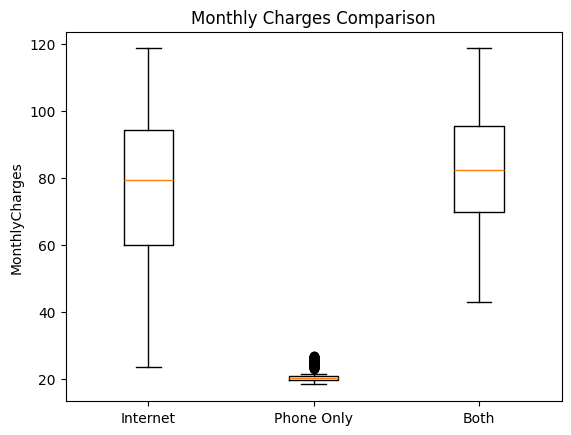

In [24]:
plt.figure()
plt.boxplot([internet_group, phone_only_group, both_group], labels=["Internet", "Phone Only", "Both"])
plt.xticks([1,2,3], ["Internet", "Phone Only", "Both"])
plt.ylabel("MonthlyCharges")
plt.title("Monthly Charges Comparison")
plt.show()

### Is it relate to churn rate

In [29]:
pd.crosstab(df["InternetService"], df["Churn"])

Churn,No,Yes
InternetService,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


In [32]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

In [34]:
yes = df[df["Churn"] == "Yes"]["MonthlyCharges"]
no = df[df["Churn"] == "No"]["MonthlyCharges"]

t_stat, p_value = ttest_ind(yes, no)
print(p_value)

2.706645606888385e-60


dataset นี้ คนที่จ่ายแพงมี churn rate สูงกว่าโดยเฉลี่ย

ค่า p-value เกณฑ์ทั่วไปคือ:
- p < 0.05 → มีนัยสำคัญ
- mp < 0.01 → มีนัยสำคัญมาก
- p < 0.001 → มีนัยสำคัญมาก ๆ

ค้าของเรา = 10⁻⁶⁰  
++นี่คือ มีนัยสำคัญสูงมาก

Customers who churn pay significantly higher Monthly Charges (Mean = 74.44) compared to retained customers (Mean = 61.27), with a statistically significant difference (p < 0.001). This suggests pricing level may be associated with churn behavior.